# GNN for Airline Fare Prediction

Edge-level regression on an airport route graph. Airports are **nodes**, routes are directed **edges**, and the target is `MARKET_FARE`. A Graph Neural Network aggregates hub-neighborhood context (competition, connectivity) that a simple distance regression cannot capture.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GATConv

sns.set_theme(style='whitegrid')
BLUE = '#4393c3'
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

PyTorch 2.12.0.dev20260321+cu128  |  CUDA: True


## 1. Data Loading & Filtering

Load the clean dataset, apply quality filters, then draw a stratified 10% sample (by ORIGIN airport) to keep the graph connected while fitting in memory. Raw individual ticket rows are kept — no pre-aggregation, since the GNN learns to aggregate information via message passing.

In [9]:
DATA_PATH = '../../data/clean_data/T_DB1B_MARKET_CLEAN.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw:  {len(df):,} rows")

# Quality filters:
#   BULK_FARE == 0              — exclude employee/contract fares
#   MKT_GEO_TYPE == 2           — domestic contiguous US only
df = df[
    (df['BULK_FARE'] == 0) &
    (df['MKT_GEO_TYPE'] == 2)
].copy()
print(f"After filters: {len(df):,} rows ({len(df)/32_520_273:.1%} retained)")

# 10% stratified sample by ORIGIN — keeps graph connected (all hub airports represented)
# No aggregation: raw ticket rows preserve fare variance that GNN/GAT learn from
agg = df.groupby('ORIGIN').sample(frac=0.05, random_state=42).reset_index(drop=True)
print(f"Sample: {len(agg):,} rows")
agg.head()

Raw:  25,072,315 rows
After filters: 23,941,830 rows (73.6% retained)
Sample: 1,197,087 rows


,YEAR,QUARTER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,REPORTING_CARRIER,TICKET_CARRIER,OPERATING_CARRIER,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON
0,2025,2,10135,ABE,13577,MYR,G4,G4,G4,0.0,2.0,88.00,518.0,518.0,2,40.6521,-75.440804,33.679699,-78.928299
1,2025,2,10135,ABE,12266,IAH,UA,UA,99,0.0,1.0,470.50,1580.0,1339.0,2,40.6521,-75.440804,29.984400,-95.341400
2,2024,4,10135,ABE,13930,ORD,G7,UA,G7,0.0,1.0,212.00,655.0,655.0,2,40.6521,-75.440804,41.978600,-87.904800
3,2025,2,10135,ABE,10397,ATL,9E,DL,9E,0.0,1.0,474.00,692.0,692.0,2,40.6521,-75.440804,33.636700,-84.428101
4,2024,3,10135,ABE,11298,DFW,AA,99,99,0.0,1.0,160.96,1358.0,1307.0,2,40.6521,-75.440804,32.896801,-97.038002


In [10]:
#print out format of data
print(agg.dtypes)

YEAR                   int64
QUARTER                int64
ORIGIN_AIRPORT_ID      int64
ORIGIN                object
DEST_AIRPORT_ID        int64
DEST                  object
REPORTING_CARRIER     object
TICKET_CARRIER        object
OPERATING_CARRIER     object
BULK_FARE            float64
PASSENGERS           float64
MARKET_FARE          float64
MARKET_DISTANCE      float64
NONSTOP_MILES        float64
MKT_GEO_TYPE           int64
ORIGIN_LAT           float64
ORIGIN_LON           float64
DEST_LAT             float64
DEST_LON             float64
dtype: object


## 2. Feature Engineering

**Node features** (per airport, computed from train set only to avoid leakage): out-degree, mean departing fare. Lat/lon excluded — airport identity is already captured by ORIGIN/DEST dummies in the Ridge/MLP and by graph topology in the GNN/GAT.

**Edge features** (per raw ticket row): log distance, cyclic quarter encoding (sin/cos so Q4→Q1 wraps correctly), passengers, carrier as a learned embedding.

**Target**: `log(MARKET_FARE)` — log-transform stabilises MSE training on the right-skewed fare distribution.

In [11]:
# ── Temporal split masks ──────────────────────────────────────────────────────
train_mask = (agg['YEAR'] == 2024)                               # Q3 + Q4 2024
val_mask   = (agg['YEAR'] == 2025) & (agg['QUARTER'] == 1)      # Q1 2025
test_mask  = (agg['YEAR'] == 2025) & (agg['QUARTER'] == 2)      # Q2 2025

train_df = agg[train_mask]
print(f"Train: {train_mask.sum():,}  Val: {val_mask.sum():,}  Test: {test_mask.sum():,}")

# ── Airport index ─────────────────────────────────────────────────────────────
all_airports = pd.unique(pd.concat([agg['ORIGIN'], agg['DEST']]))
airport_to_idx = {a: i for i, a in enumerate(all_airports)}
num_airports = len(all_airports)
print(f"Unique airports: {num_airports}")

# ── Node features (fit on train only, no lat/lon) ─────────────────────────────
node_stats = (
    train_df.groupby('ORIGIN')
    .agg(degree   =('DEST',        'nunique'),
         mean_fare =('MARKET_FARE', 'mean'))
    .reindex(all_airports, fill_value=0)
)
node_scaler = StandardScaler()
node_feat_cols = ['degree', 'mean_fare']
node_features = torch.tensor(
    node_scaler.fit_transform(node_stats[node_feat_cols].values),
    dtype=torch.float
)
print(f"Node feature matrix: {node_features.shape}")

# ── Carrier encoding ──────────────────────────────────────────────────────────
carriers = agg['TICKET_CARRIER'].unique()
carrier_to_idx = {c: i for i, c in enumerate(carriers)}
num_carriers = len(carriers)
print(f"Unique carriers: {num_carriers}")

# ── Feature engineering ───────────────────────────────────────────────────────
agg['log_distance']          = np.log1p(agg['MARKET_DISTANCE'])
agg['sin_q']                 = np.sin(2 * np.pi * (agg['QUARTER'] - 1) / 4)
agg['cos_q']                 = np.cos(2 * np.pi * (agg['QUARTER'] - 1) / 4)
agg['detour_ratio']          = agg['MARKET_DISTANCE'] / agg['NONSTOP_MILES']
agg['lon_spread']            = (agg['ORIGIN_LON'] - agg['DEST_LON']).abs()
agg['is_short_haul']         = (agg['MARKET_DISTANCE'] < 500).astype(int)
agg['route_total_passengers']= agg.groupby(['ORIGIN','DEST','YEAR','QUARTER'])['PASSENGERS'].transform('sum')

agg['carrier_idx'] = agg['TICKET_CARRIER'].map(carrier_to_idx)
agg['log_fare']    = np.log(agg['MARKET_FARE'])
agg['src_idx']     = agg['ORIGIN'].map(airport_to_idx)
agg['dst_idx']     = agg['DEST'].map(airport_to_idx)

# ── Edge feature matrix (scaler fit on train only) ────────────────────────────
edge_feat_cols = [
    'log_distance', 'sin_q', 'cos_q', 'PASSENGERS',
    'detour_ratio', 'lon_spread', 'is_short_haul', 'route_total_passengers',
]
edge_scaler = StandardScaler()
edge_scaler.fit(agg.loc[train_mask, edge_feat_cols].values)
edge_feats = edge_scaler.transform(agg[edge_feat_cols].values)

print(f"Edge feature matrix: {edge_feats.shape}")

Train: 622,247  Val: 263,763  Test: 311,077
Unique airports: 397
Node feature matrix: torch.Size([397, 2])
Unique carriers: 23
Edge feature matrix: (1197087, 8)


## 3. Graph Construction (PyTorch Geometric)

One global graph — all quarters share the same node set (airports). Quarter and carrier are encoded as edge features, so a single `Data` object holds the full dataset with per-edge targets and split masks.

In [12]:
edge_index  = torch.tensor(agg[['src_idx', 'dst_idx']].values.T, dtype=torch.long)
edge_attr   = torch.tensor(edge_feats, dtype=torch.float)
carrier_ids = torch.tensor(agg['carrier_idx'].values, dtype=torch.long)
y           = torch.tensor(agg['log_fare'].values, dtype=torch.float)

train_idx = torch.where(torch.tensor(train_mask.values))[0]
val_idx   = torch.where(torch.tensor(val_mask.values))[0]
test_idx  = torch.where(torch.tensor(test_mask.values))[0]

data = Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, y=y)
data.carrier_ids = carrier_ids

print(f"Graph — nodes: {data.num_nodes:,}  |  edges: {data.num_edges:,}")
print(f"Node feat dim: {data.num_node_features}  |  Edge feat dim: {data.num_edge_features}")
print(f"Train edges: {len(train_idx):,}  Val: {len(val_idx):,}  Test: {len(test_idx):,}")

Graph — nodes: 397  |  edges: 1,197,087
Node feat dim: 2  |  Edge feat dim: 8
Train edges: 622,247  Val: 263,763  Test: 311,077


## 4. Baseline — Enhanced Ridge Regression

Ridge regression with a rich fixed-effects feature set: log-distance, cyclic quarter, year, one-hot ORIGIN (400 airports), DEST (400 airports), TICKET_CARRIER, and REPORTING_CARRIER. This is a strong benchmark — it captures most route-level fixed effects that a simple linear model can recover. The GNN must beat this to demonstrate that graph neighborhood context adds genuine value beyond what dummy variables already encode.

> **Note:** `MKT_GEO_TYPE` is excluded — it is filtered to the constant value `2` before aggregation, so it carries zero information.

In [13]:
def eval_dollars(y_true_log, y_pred_log):
    """Return (RMSE $, MAE $, R² on log scale)."""
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    r2   = r2_score(y_true_log, y_pred_log)
    return rmse, mae, r2

num_cols = ['log_distance', 'sin_q', 'cos_q', 'YEAR', 'PASSENGERS',
            'detour_ratio', 'lon_spread', 'is_short_haul', 'route_total_passengers']
cat_cols = ['TICKET_CARRIER', 'REPORTING_CARRIER', 'ORIGIN', 'DEST']
X_cols   = num_cols + cat_cols

X = agg[X_cols].copy()
y_np = agg['log_fare'].values

X_train, y_train = X[train_mask], y_np[train_mask]
X_val,   y_val   = X[val_mask],   y_np[val_mask]
X_test,  y_test  = X[test_mask],  y_np[test_mask]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])
baseline = Pipeline([('pre', preprocessor), ('reg', Ridge())])
baseline.fit(X_train, y_train)

bl_val  = baseline.predict(X_val)
bl_test = baseline.predict(X_test)

rmse_v, mae_v, r2_v = eval_dollars(y_val,  bl_val)
rmse_t, mae_t, r2_t = eval_dollars(y_test, bl_test)
print(f"Ridge+  Val  — RMSE: ${rmse_v:.1f}  MAE: ${mae_v:.1f}  R²: {r2_v:.3f}")
print(f"Ridge+  Test — RMSE: ${rmse_t:.1f}  MAE: ${mae_t:.1f}  R²: {r2_t:.3f}")

Ridge+  Val  — RMSE: $109.5  MAE: $84.3  R²: 0.286
Ridge+  Test — RMSE: $107.1  MAE: $80.2  R²: 0.298


## 5. MLP — Multilayer Perceptron

Same feature set as the enhanced Ridge (same `ColumnTransformer` preprocessing), but non-linear. A 3-hidden-layer feedforward network with BatchNorm and Dropout. Isolates whether non-linear combinations of route fixed effects help — before introducing graph structure.

Architecture: `Input (~870) → 256 → 128 → 64 → 1`

In [ ]:
# ── Preprocess with the same pipeline as Ridge ────────────────────────────────
# Reuse the fitted preprocessor so features are identical (OHE + numeric including PASSENGERS)
X_train_np = preprocessor.transform(X_train).astype(np.float32)
X_val_np   = preprocessor.transform(X_val).astype(np.float32)
X_test_np  = preprocessor.transform(X_test).astype(np.float32)
input_dim  = X_train_np.shape[1]
print(f"MLP input dim: {input_dim}")

X_tr_t  = torch.tensor(X_train_np)
X_va_t  = torch.tensor(X_val_np)
X_te_t  = torch.tensor(X_test_np)
y_tr_t  = torch.tensor(y_train.astype(np.float32))
y_va_t  = torch.tensor(y_val.astype(np.float32))

# ── Model ─────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(256, 128, 64), dropout=0.2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

mlp_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mlp_model  = MLP(input_dim).to(mlp_device)
n_params   = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(mlp_model)
print(f"\nTrainable parameters: {n_params:,}")

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 4096
optimizer  = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-5)
dataset    = torch.utils.data.TensorDataset(X_tr_t, y_tr_t)
loader     = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

X_va_d = X_va_t.to(mlp_device)
y_va_d = y_va_t.to(mlp_device)

mlp_train_losses, mlp_val_losses = [], []
best_mlp_val, best_mlp_state, mlp_patience_ctr = float('inf'), None, 0
PATIENCE = 50

for epoch in range(1, 501):
    mlp_model.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(mlp_device), yb.to(mlp_device)
        optimizer.zero_grad()
        loss = F.mse_loss(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(dataset)

    mlp_model.eval()
    with torch.no_grad():
        val_loss = F.mse_loss(mlp_model(X_va_d), y_va_d).item()

    mlp_train_losses.append(epoch_loss)
    mlp_val_losses.append(val_loss)

    if val_loss < best_mlp_val:
        best_mlp_val   = val_loss
        best_mlp_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}
        mlp_patience_ctr = 0
    else:
        mlp_patience_ctr += 1
        if mlp_patience_ctr >= PATIENCE:
            print(f"Early stop at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train: {epoch_loss:.4f}  val: {val_loss:.4f}")

mlp_model.load_state_dict(best_mlp_state)
print(f"\nBest MLP val loss: {best_mlp_val:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_train_losses, label='Train', color='#4393c3')
ax.plot(mlp_val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('MLP Training Curve'); ax.legend()
plt.tight_layout(); plt.show()

# ── Eval ──────────────────────────────────────────────────────────────────────
mlp_model.eval()
with torch.no_grad():
    mlp_val_pred  = mlp_model(X_va_t.to(mlp_device)).cpu().numpy()
    mlp_test_pred = mlp_model(X_te_t.to(mlp_device)).cpu().numpy()

mlp_rmse_v, mlp_mae_v, mlp_r2_v = eval_dollars(y_val,  mlp_val_pred)
mlp_rmse_t, mlp_mae_t, mlp_r2_t = eval_dollars(y_test, mlp_test_pred)
print(f"MLP     Val  — RMSE: ${mlp_rmse_v:.1f}  MAE: ${mlp_mae_v:.1f}  R²: {mlp_r2_v:.3f}")
print(f"MLP     Test — RMSE: ${mlp_rmse_t:.1f}  MAE: ${mlp_mae_t:.1f}  R²: {mlp_r2_t:.3f}")

MLP input dim: 828
MLP(
  (net): Sequential(
    (0): Linear(in_features=828, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 254,337
Epoch  10  train: 0.4274  val: 0.1653
Epoch  20  train: 0.3457  val: 0.1714
Epoch  30  train: 0.3042  val: 0.1630
Epoch  40  train: 0.2593  val: 0.1608
Epoch  50  train: 0.2220  val: 0.1571
Epoch  60  tra

## 6. GNN Model — EdgeGNN

Architecture:
1. **NodeEncoder**: linear projection of node features → hidden dimension
2. **2× SAGEConv**: message-passing layers that aggregate hub-neighborhood context
3. **EdgeDecoder**: MLP on `[src_emb ‖ dst_emb ‖ edge_feats ‖ carrier_emb]` → predicted log-fare

Carrier is a learned `nn.Embedding` (8-dim) rather than one-hot, which handles rare carriers and captures latent pricing similarities. Unlike Ridge and MLP, the GNN sees the full graph topology — each airport's embedding reflects its hub connections, competition, and pricing neighbourhood.

In [8]:
class EdgeGNN(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, num_carriers,
                 hidden_dim=128, carrier_emb_dim=8, dropout=0.1):
        super().__init__()
        self.carrier_emb = nn.Embedding(num_carriers, carrier_emb_dim)
        self.node_enc    = nn.Linear(node_feat_dim, hidden_dim)
        self.conv1       = SAGEConv(hidden_dim, hidden_dim)
        self.conv2       = SAGEConv(hidden_dim, hidden_dim)

        dec_in = 2 * hidden_dim + edge_feat_dim + carrier_emb_dim
        self.decoder = nn.Sequential(
            nn.Linear(dec_in, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x, edge_index, edge_attr, carrier_ids):
        h = F.relu(self.node_enc(x))
        h = F.relu(self.conv1(h, edge_index))
        h = F.relu(self.conv2(h, edge_index))

        src, dst = edge_index
        carrier_e = self.carrier_emb(carrier_ids)
        edge_in   = torch.cat([h[src], h[dst], edge_attr, carrier_e], dim=-1)
        return self.decoder(edge_in).squeeze(-1)


model = EdgeGNN(
    node_feat_dim  = node_features.shape[1],
    edge_feat_dim  = edge_attr.shape[1],
    num_carriers   = num_carriers,
    hidden_dim     = 128,
)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

EdgeGNN(
  (carrier_emb): Embedding(24, 8)
  (node_enc): Linear(in_features=2, out_features=128, bias=True)
  (conv1): SAGEConv(128, 128, aggr=mean)
  (conv2): SAGEConv(128, 128, aggr=mean)
  (decoder): Sequential(
    (0): Linear(in_features=268, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 109,121


## 7. GNN Training

Full-graph training (all edges fit in memory). Adam with weight decay, MSE loss on log-fare, early stopping on validation loss with patience=100.

Training on: cuda
Epoch  10  train: 4.2789  val: 0.5413
Epoch  20  train: 1.9838  val: 2.2424
Epoch  30  train: 1.0325  val: 1.1654
Epoch  40  train: 0.6408  val: 0.4433
Epoch  50  train: 0.3435  val: 0.2360
Epoch  60  train: 0.2811  val: 0.2307
Epoch  70  train: 0.2843  val: 0.2057
Epoch  80  train: 0.2689  val: 0.1996
Epoch  90  train: 0.2643  val: 0.2004
Epoch 100  train: 0.2584  val: 0.1949
Epoch 110  train: 0.2537  val: 0.1903
Epoch 120  train: 0.2480  val: 0.1866
Epoch 130  train: 0.2392  val: 0.1798
Epoch 140  train: 0.2298  val: 0.1761
Epoch 150  train: 0.2256  val: 0.1756
Epoch 160  train: 0.2224  val: 0.1758
Epoch 170  train: 0.2185  val: 0.1743
Epoch 180  train: 0.2147  val: 0.1732
Epoch 190  train: 0.2128  val: 0.1727
Epoch 200  train: 0.2116  val: 0.1721
Epoch 210  train: 0.2105  val: 0.1717
Epoch 220  train: 0.2096  val: 0.1733
Epoch 230  train: 0.2091  val: 0.1729
Epoch 240  train: 0.2078  val: 0.1726
Epoch 250  train: 0.2068  val: 0.1700
Epoch 260  train: 0.2063  val: 0

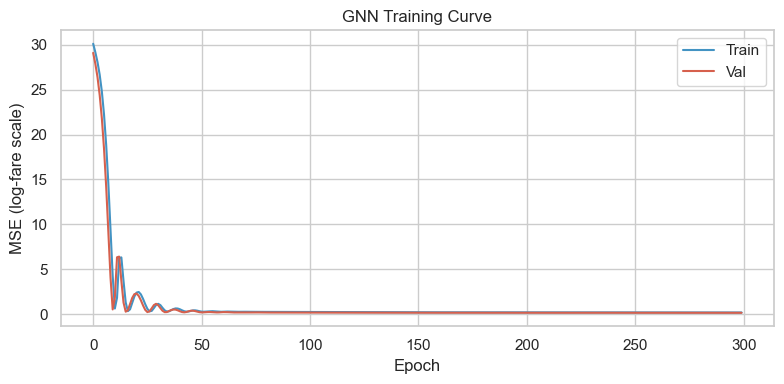

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = EdgeGNN(
    node_feat_dim = node_features.shape[1],
    edge_feat_dim = edge_attr.shape[1],
    num_carriers  = num_carriers,
    hidden_dim    = 128,
).to(device)

x_d    = data.x.to(device)
ei_d   = data.edge_index.to(device)
ea_d   = data.edge_attr.to(device)
cids_d = data.carrier_ids.to(device)
y_d    = data.y.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience, patience_ctr = 100, 0
best_state = None

for epoch in range(1, 301):
    model.train()
    optimizer.zero_grad()
    pred = model(x_d, ei_d, ea_d, cids_d)
    loss = F.mse_loss(pred[train_idx], y_d[train_idx])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_all = model(x_d, ei_d, ea_d, cids_d)
        val_loss = F.mse_loss(pred_all[val_idx], y_d[val_idx]).item()

    train_losses.append(loss.item())
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"Early stop at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train: {loss.item():.4f}  val: {val_loss:.4f}")

model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train', color='#4393c3')
ax.plot(val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('GNN Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 8. GAT Model — EdgeGAT

Graph Attention Network variant. Identical EdgeDecoder to the GNN, but replaces SAGEConv with **GATConv** — attention weights are computed per-neighbor using edge features (`edge_dim`), so the model learns *which* connections matter most for fare prediction rather than averaging uniformly.

Architecture:
1. **NodeEncoder**: linear projection → hidden dim
2. **2× GATConv** (4 heads → 1 head): attention-weighted message passing with edge features
3. **EdgeDecoder**: same MLP on `[src_emb ‖ dst_emb ‖ edge_feats ‖ carrier_emb]` → log-fare

EdgeGAT(
  (carrier_emb): Embedding(24, 8)
  (node_enc): Linear(in_features=2, out_features=128, bias=True)
  (conv1): GATConv(128, 32, heads=4)
  (conv2): GATConv(128, 128, heads=1)
  (decoder): Sequential(
    (0): Linear(in_features=268, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 78,145
Epoch  10  train: 8.7645  val: 4.7706
Epoch  20  train: 0.3022  val: 0.5736
Epoch  30  train: 0.3938  val: 0.2311
Epoch  40  train: 0.2799  val: 0.2866
Epoch  50  train: 0.2720  val: 0.2372
Epoch  60  train: 0.3364  val: 0.2618
Epoch  70  train: 0.2911  val: 0.2091
Epoch  80  train: 0.2546  val: 0.1986
Epoch  90  train: 0.2474  val: 0.1931
Epoch 100  train: 0.2450  val: 0.1915
Epoch 110  train: 0.2475  val: 0.2030
Epoch 120  train: 0.2414  val: 0.1891
Epoch 130  train: 0.2402  val: 0.1917
Epoch 140

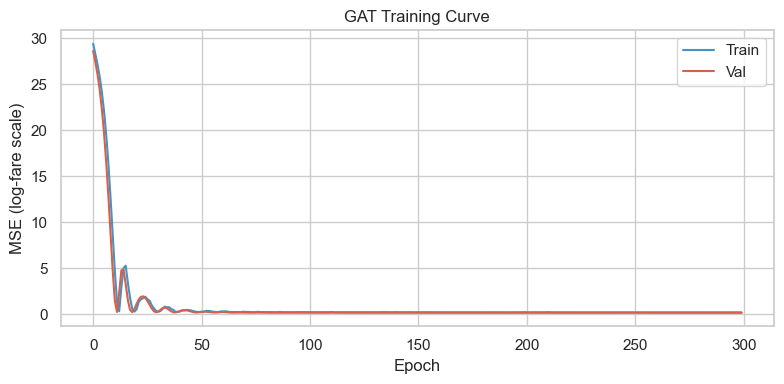

In [10]:
# ── Model ─────────────────────────────────────────────────────────────────────
class EdgeGAT(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, num_carriers,
                 hidden_dim=128, heads=4, carrier_emb_dim=8, dropout=0.1):
        super().__init__()
        self.carrier_emb = nn.Embedding(num_carriers, carrier_emb_dim)
        self.node_enc    = nn.Linear(node_feat_dim, hidden_dim)
        # GATConv with edge_dim feeds edge features into the attention coefficient
        self.conv1 = GATConv(hidden_dim, hidden_dim // heads, heads=heads,
                             edge_dim=edge_feat_dim, dropout=dropout)
        self.conv2 = GATConv(hidden_dim, hidden_dim, heads=1,
                             edge_dim=edge_feat_dim, dropout=dropout)

        dec_in = 2 * hidden_dim + edge_feat_dim + carrier_emb_dim
        self.decoder = nn.Sequential(
            nn.Linear(dec_in, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),     nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x, edge_index, edge_attr, carrier_ids):
        h = F.relu(self.node_enc(x))
        h = F.relu(self.conv1(h, edge_index, edge_attr=edge_attr))
        h = F.relu(self.conv2(h, edge_index, edge_attr=edge_attr))
        src, dst  = edge_index
        carrier_e = self.carrier_emb(carrier_ids)
        edge_in   = torch.cat([h[src], h[dst], edge_attr, carrier_e], dim=-1)
        return self.decoder(edge_in).squeeze(-1)


gat_model = EdgeGAT(
    node_feat_dim = node_features.shape[1],
    edge_feat_dim = edge_attr.shape[1],
    num_carriers  = num_carriers,
    hidden_dim    = 128,
).to(device)
n_params = sum(p.numel() for p in gat_model.parameters() if p.requires_grad)
print(gat_model)
print(f"\nTrainable parameters: {n_params:,}")

# ── Training ──────────────────────────────────────────────────────────────────
optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=1e-3, weight_decay=1e-5)

gat_train_losses, gat_val_losses = [], []
best_gat_val, best_gat_state, gat_patience_ctr = float('inf'), None, 0
PATIENCE_GAT = 100

for epoch in range(1, 301):
    gat_model.train()
    optimizer_gat.zero_grad()
    pred = gat_model(x_d, ei_d, ea_d, cids_d)
    loss = F.mse_loss(pred[train_idx], y_d[train_idx])
    loss.backward()
    optimizer_gat.step()

    gat_model.eval()
    with torch.no_grad():
        pred_all = gat_model(x_d, ei_d, ea_d, cids_d)
        val_loss = F.mse_loss(pred_all[val_idx], y_d[val_idx]).item()

    gat_train_losses.append(loss.item())
    gat_val_losses.append(val_loss)

    if val_loss < best_gat_val:
        best_gat_val   = val_loss
        best_gat_state = {k: v.clone() for k, v in gat_model.state_dict().items()}
        gat_patience_ctr = 0
    else:
        gat_patience_ctr += 1
        if gat_patience_ctr >= PATIENCE_GAT:
            print(f"Early stop at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train: {loss.item():.4f}  val: {val_loss:.4f}")

gat_model.load_state_dict(best_gat_state)
print(f"\nBest GAT val loss: {best_gat_val:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gat_train_losses, label='Train', color='#4393c3')
ax.plot(gat_val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('GAT Training Curve'); ax.legend()
plt.tight_layout(); plt.show()

## 9. Model Comparison

All four models evaluated on the held-out test set (2025 Q2). Metrics in original dollar scale for interpretability. Expected ordering: GAT ≥ GNN ≥ MLP ≥ Ridge+.

Model        Split   RMSE ($)   MAE ($)      R²
-------------------------------------------------------------
Ridge+       Val       109.7      84.5   0.282
Ridge+       Test      107.4      80.6   0.290
-------------------------------------------------------------
MLP          Val       107.9      82.1   0.328
MLP          Test      105.4      78.9   0.325
-------------------------------------------------------------
GNN          Val       110.4      84.5   0.281
GNN          Test      108.4      80.7   0.288
-------------------------------------------------------------
GAT          Val       112.8      86.9   0.229
GAT          Test      110.5      83.0   0.233
-------------------------------------------------------------


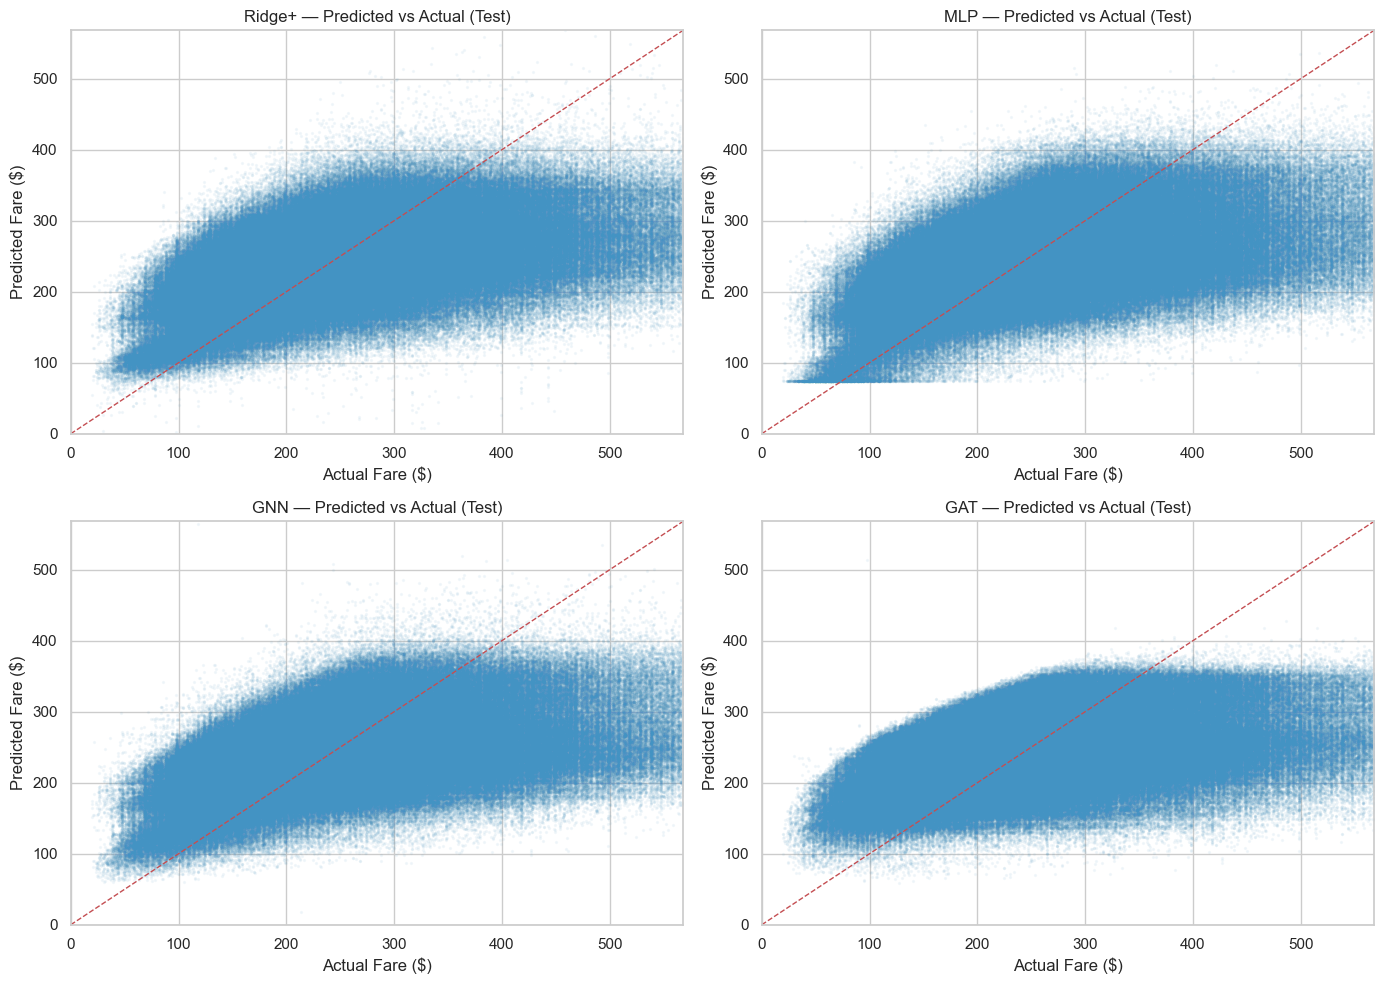

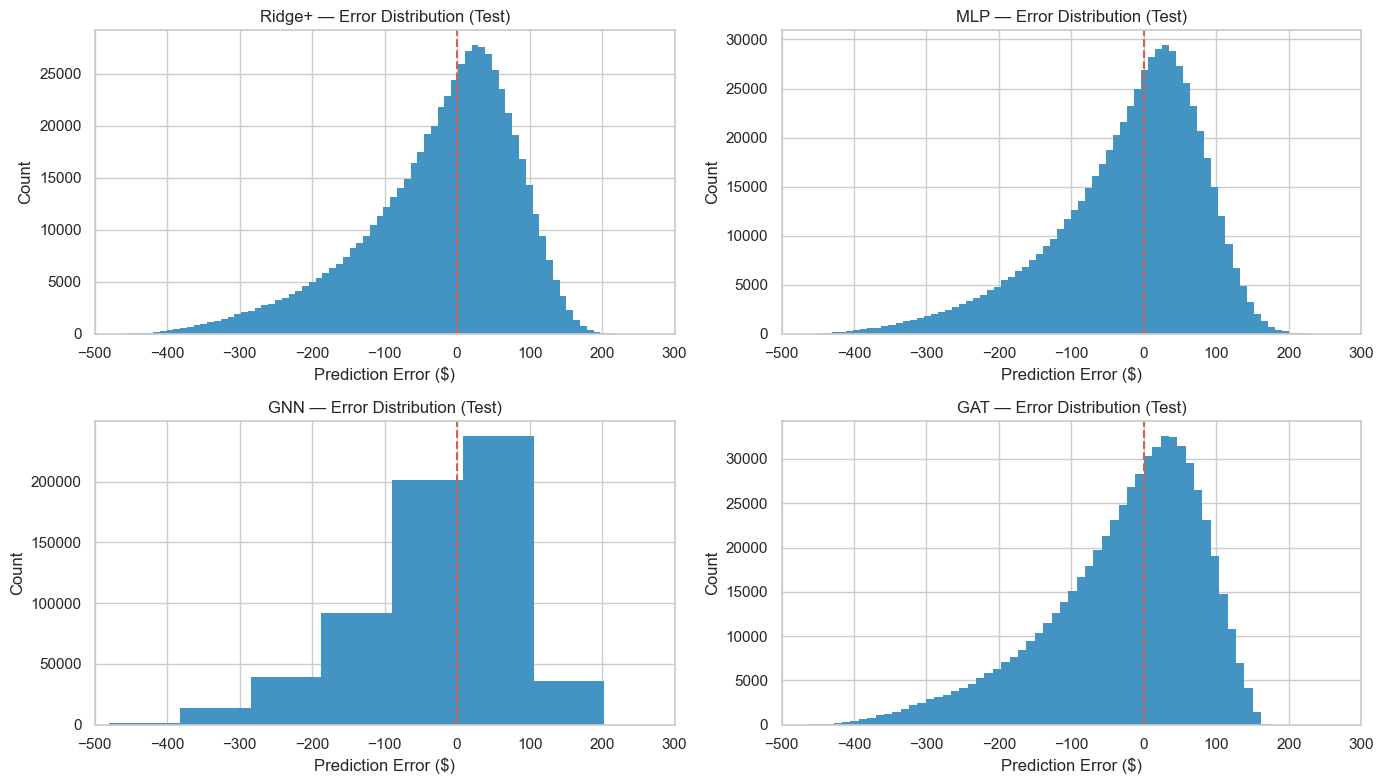


Median absolute error (test):
  Ridge+     $62.0
  MLP        $60.7
  GNN        $61.7
  GAT        $64.3


In [12]:
model.eval()
gat_model.eval()
with torch.no_grad():
    pred_log     = model(x_d, ei_d, ea_d, cids_d).cpu().numpy()
    gat_pred_log = gat_model(x_d, ei_d, ea_d, cids_d).cpu().numpy()

y_np_all = y_d.cpu().numpy()

gnn_val  = eval_dollars(y_np_all[val_idx],  pred_log[val_idx])
gnn_test = eval_dollars(y_np_all[test_idx], pred_log[test_idx])
gat_val  = eval_dollars(y_np_all[val_idx],  gat_pred_log[val_idx])
gat_test = eval_dollars(y_np_all[test_idx], gat_pred_log[test_idx])

# ── Summary Table ─────────────────────────────────────────────────────────────
print("=" * 61)
print(f"{'Model':<12} {'Split':<6} {'RMSE ($)':>9} {'MAE ($)':>9} {'R²':>7}")
print("-" * 61)
for label, rv, rt in [
    ('Ridge+', (rmse_v,     mae_v,     r2_v),     (rmse_t,     mae_t,     r2_t)),
    ('MLP',    (mlp_rmse_v, mlp_mae_v, mlp_r2_v), (mlp_rmse_t, mlp_mae_t, mlp_r2_t)),
    ('GNN',    gnn_val,                            gnn_test),
    ('GAT',    gat_val,                            gat_test),
]:
    rmse_rv, mae_rv, r2_rv = rv
    rmse_rt, mae_rt, r2_rt = rt
    print(f"{label:<12} {'Val':<6} {rmse_rv:>8.1f}  {mae_rv:>8.1f}  {r2_rv:>6.3f}")
    print(f"{label:<12} {'Test':<6} {rmse_rt:>8.1f}  {mae_rt:>8.1f}  {r2_rt:>6.3f}")
    print("-" * 61)

# ── Predicted vs Actual (Test) — all 4 models ─────────────────────────────────
y_true_test = np.exp(y_np_all[test_idx])
preds_test = {
    'Ridge+': bl_test,
    'MLP':    mlp_test_pred,
    'GNN':    pred_log[test_idx],
    'GAT':    gat_pred_log[test_idx],
}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (label, y_pred_log) in zip(axes.flat, preds_test.items()):
    y_pred = np.exp(y_pred_log)
    ax.scatter(y_true_test, y_pred, alpha=0.05, s=2, color=BLUE)
    lim = np.percentile(np.concatenate([y_true_test, y_pred]), 99)
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Actual Fare ($)'); ax.set_ylabel('Predicted Fare ($)')
    ax.set_title(f'{label} — Predicted vs Actual (Test)')
plt.tight_layout(); plt.show()

# ── Error Distribution (Test) ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (label, y_pred_log) in zip(axes.flat, preds_test.items()):
    errors = np.exp(y_pred_log) - y_true_test
    ax.hist(errors, bins=80, color=BLUE, edgecolor='none')
    ax.axvline(0, color='#d6604d', linestyle='--', linewidth=1.5)
    ax.set_xlim(-500, 300)
    ax.set_xlabel('Prediction Error ($)'); ax.set_ylabel('Count')
    ax.set_title(f'{label} — Error Distribution (Test)')
plt.tight_layout(); plt.show()

print("\nMedian absolute error (test):")
for label, y_pred_log in preds_test.items():
    med = np.median(np.abs(np.exp(y_pred_log) - y_true_test))
    print(f"  {label:<10} ${med:.1f}")